# Authors
- Raphael Wäspi (18-918-938)
- Nicolas Huber (16-936-205)

In [2]:
import math

# Imports
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import os
import glob
import re
import random
from statistics import mean 
from tqdm import tqdm
import shutil

In [3]:
# Define colors with reduced opacity from a colormap
COLOR_BLUE = 'dodgerblue'
COLOR_RED = 'lightcoral'
COLOR_GREY = 'slategrey'

# Define the main data directory
OUTPUT_PATH = "./output"

In [4]:
# Prepare output folder

# Delete the entire 'output' directory and its contents
if os.path.exists(OUTPUT_PATH):
    shutil.rmtree(OUTPUT_PATH)

# Create the 'output' directory
os.makedirs(OUTPUT_PATH)

# Define subdirectories
OUTPUT_PATH_ER = os.path.join(OUTPUT_PATH, "erdos_renyi_avg_clustering")
OUTPUT_PATH_WS = os.path.join(OUTPUT_PATH, "watts_strogatz_model")

# Recreate the subdirectories
os.makedirs(OUTPUT_PATH_ER)
os.makedirs(OUTPUT_PATH_WS)

In [5]:
# Define the directory containing the .gml files
directory = 'assignment_02_data'

# Use glob to get a list of all .gml files in the directory
gml_files = glob.glob(os.path.join(directory, '*.gml'))

# Init an empty dictionary for all graphs - the key is the actual name, and the value is the graph data
graphs = {}

# Use tqdm to show a progress bar in Jupyter Notebook
with tqdm(total=len(gml_files), desc="Loading GML Files") as pbar:
    # Loop through the list of .gml files and load them
    for file_path in gml_files:
        with open(file_path, 'r') as file:
            content = file.read()
            
            # Use regex to extract the desired part
            match = re.search(r'/([^/]+)\.gml$', file_path)
            if match:
                graph_name = match.group(1)
                
                # Add to the graph dictionary
                graph = nx.read_gml(file_path)
                graphs[graph_name] = graph
                
                # Print the graph name when each part is finished
                print(f"Finished loading {graph_name}")
                
        pbar.update(1)  # Update the progress bar

Loading GML Files:  14%|█▍        | 1/7 [00:06<00:41,  6.94s/it]

Finished loading graph_internet
Finished loading graph_Korea


Loading GML Files:  57%|█████▋    | 4/7 [00:07<00:03,  1.31s/it]

Finished loading graph_eu_airlines
Finished loading graph_macaque


Loading GML Files: 100%|██████████| 7/7 [00:26<00:00,  3.77s/it]

Finished loading graph_hep-th
Finished loading graph_starwars
Finished loading graph_madrid


# I Erdos-Renyi Model

In [6]:
graphs

{'graph_internet': <networkx.classes.graph.Graph at 0x1187d7fd0>,
 'graph_Korea': <networkx.classes.graph.Graph at 0x11614c190>,
 'graph_eu_airlines': <networkx.classes.graph.Graph at 0x1164d7d90>,
 'graph_macaque': <networkx.classes.graph.Graph at 0x1161fc790>,
 'graph_hep-th': <networkx.classes.graph.Graph at 0x12064bf90>,
 'graph_starwars': <networkx.classes.graph.Graph at 0x119f27e90>,
 'graph_madrid': <networkx.classes.graph.Graph at 0x119f7bf10>}

## 1. Write a function to generate an Erdős-Rényi undirected graph G(N, p).
It should take in two input parameters:
- N: the number of nodes of the network,
- p: the probability of an edge existing between two nodes,

and it should output a network (the data structure to represent the network is left to your choice, in the
hint a suggestion is provided).

In [7]:
random.seed(a=42)

In [8]:
def generate_custom_erdos_renyi_graph(N, p):
    # Precondition
    if p < 0 or p > 1:
        raise ValueError("Probability p must be in the range [0, 1]")
    

    # Create a graph object
    G = nx.Graph()
    
    # Init N nodes 
    G.add_nodes_from(range(N))

    # Model: each pair of 𝑁 nodes is connected with edge creation probability 𝑝
    for i in range(N):
        for j in range(i + 1, N):
            # In total: N (N-1) * 0.5 possible links
            if random.random() < p: # Select node with probability p
                G.add_edge(i, j)

    return G

## 2. Using the function you wrote at point (1), generate three Erdős-Rényi networks with N = 100 nodes and link probability 
- (a) p = 0.001,
- (b) p = 0.01,
- (c) p = 0.1, and
- (d) p = 0.5.

Provide a visualisation of these networks, in order to emphasize the existence of connected components.

In [9]:
SEED = 42
N = 100
PROBABILITIES = [0.001, 0.01, 0.1, 0.5]

In [10]:
generated_networks = []

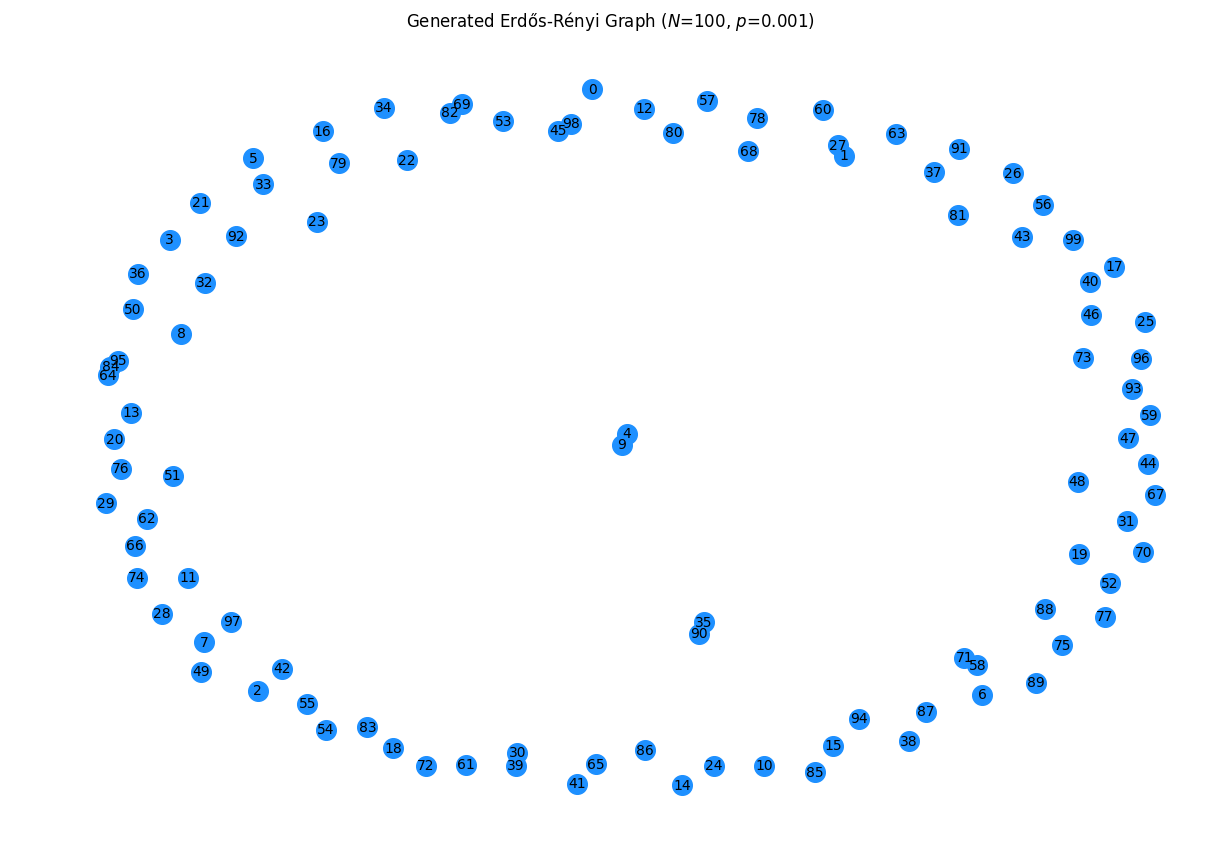

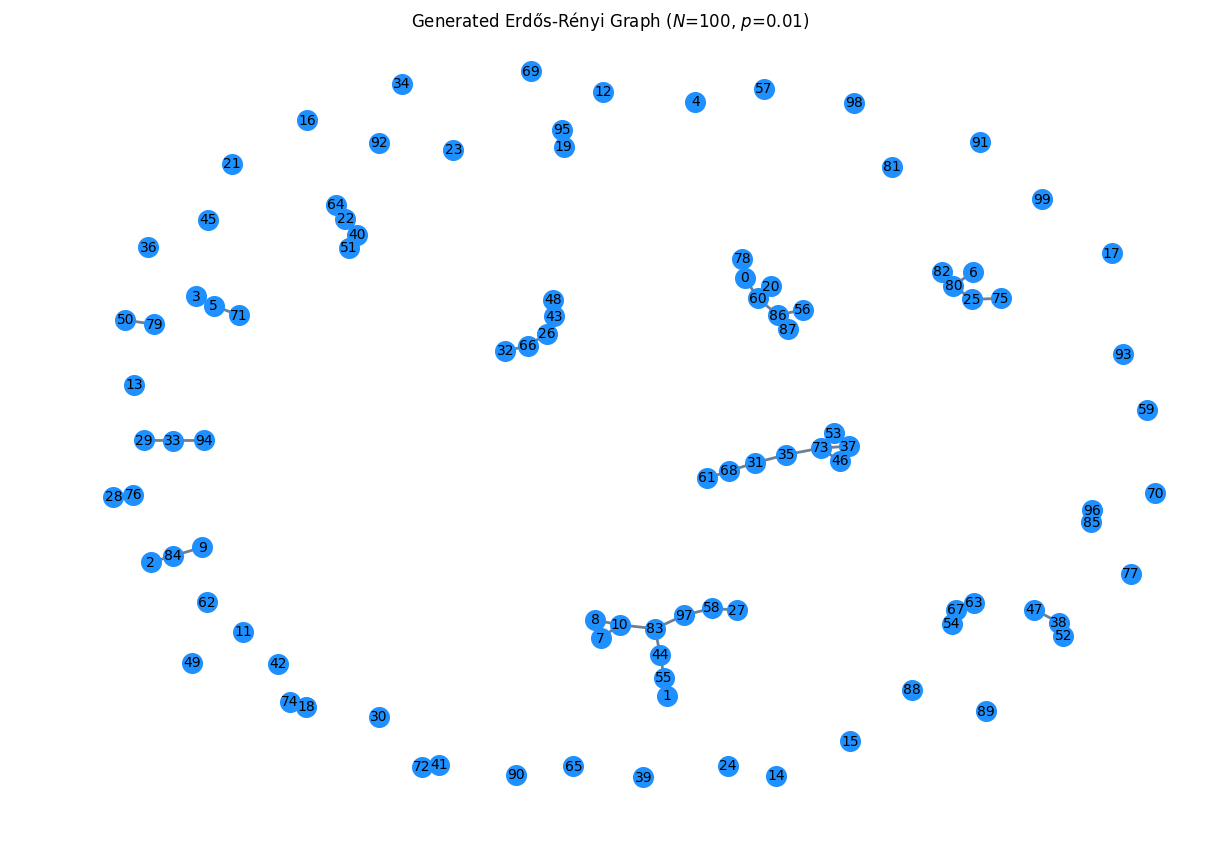

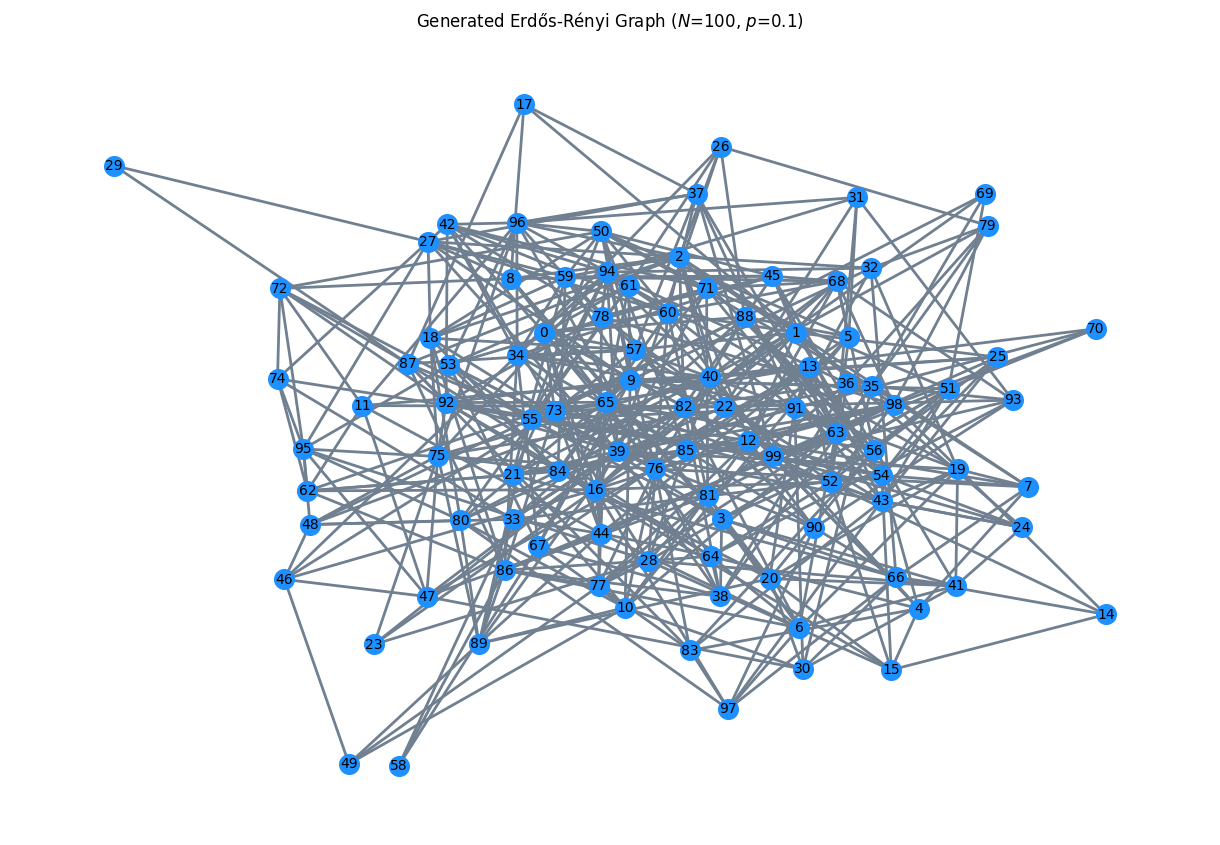

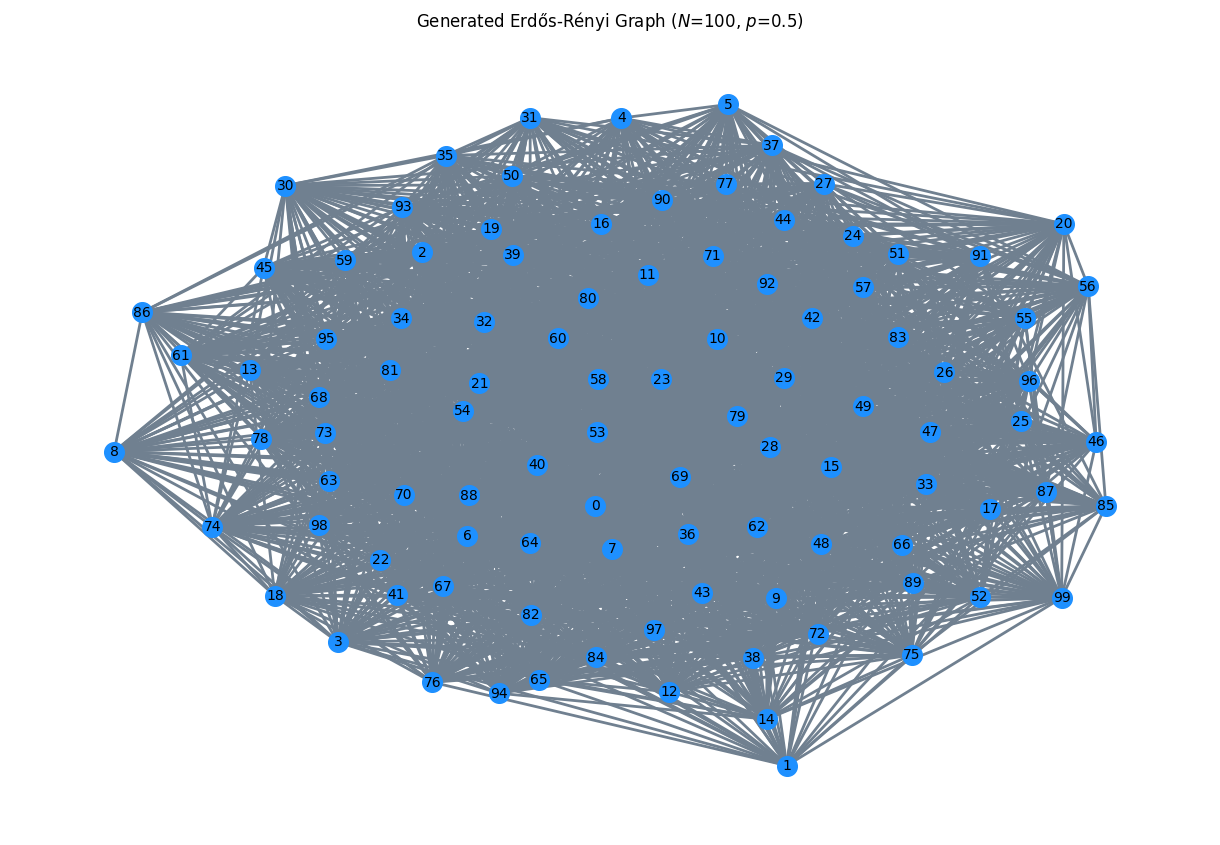

In [11]:
for p in PROBABILITIES:
    g = generate_custom_erdos_renyi_graph(N, p)
    generated_networks.append({"graph":g, "N": N, "p": p})
    pos = nx.spring_layout(G=g, seed=SEED)  # Layout algorithm for node positions
    plt.figure(figsize=(12, 8))
    nx.draw(g, pos, with_labels=True, node_size=200, node_color=COLOR_BLUE, edge_color=COLOR_GREY, width=2, font_size=10)
    plt.title(fr"Generated Erdős-Rényi Graph ($N$={N}, $p$={p})")
    plt.axis('off')
    
    file_name = f"sample_network_N{N}_p{p}.png"
    complete_plot_filename = os.path.join(OUTPUT_PATH_ER, file_name)
    plt.savefig(complete_plot_filename)
    plt.show()

## 3. Generate ER graphs with N = 100 nodes for different edge creation probabilities p ∈ [0, 1] and plot the probability that a node belongs to the largest connected component NG/N as a function of p and mark with a vertical line the critical probability pC = 1/N.

In [12]:
N = 100
sample_size = 100
probabilities_log_range = np.logspace(np.log(1e-3),np.log(0.5),200)

In [13]:
ratios_avg = {}
for p in probabilities_log_range:
    ratios = []
    
    for n in range(sample_size):
        # Generate ER graph samples for each p
        g = generate_custom_erdos_renyi_graph(N,p)
        
        # Get all components
        # https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.components.connected_components.html
        connected_components = sorted(nx.connected_components(g), key=len, reverse=True)
        
        # Get largest connected component (LCC)
        largest_connected_component = g.subgraph(connected_components[0])
        
        # Find size of lcc
        nodes_lcc = largest_connected_component.number_of_nodes()
        
        # Calculate ration N_G / N
        ratio = float(nodes_lcc / len(g))
        
        # Append to ratio sample list
        ratios.append(ratio)
    
    # Average all results in ratios to get value for a specific p
    ratios_avg[f"{p}"] = mean(ratios)

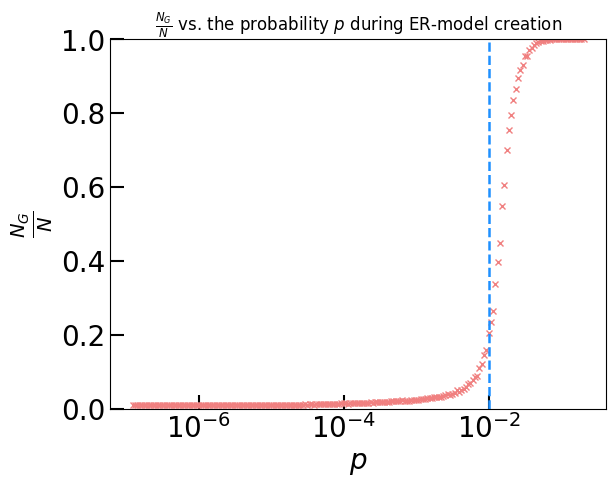

In [14]:
fig = plt.figure()
ax = fig.add_subplot(111)

ax.plot(probabilities_log_range, ratios_avg.values(), "x",  ms=5,color=COLOR_RED, label=r"$N_G / N$") # Regular values
plt.axvline(x=1./(N-1),linestyle="--", lw="1.8",color=COLOR_BLUE) # Horizontal line p_c = 1 / N

# Formatting
plt.title(r"$\frac{N_G}{N}$ vs. the probability $p$ during ER-model creation")
ax.set_xlabel(r"$p$", fontsize=20)
ax.set_ylabel(r"$\frac{N_G}{N}$", fontsize=20)
ax.tick_params(which = "major", axis='both', width=1.5, length = 10, labelsize=20,direction="in")
ax.tick_params(which = "minor", axis='both', width=1.5, length = 5, labelsize=20,direction="in")
plt.yticks(fontsize = 20)
plt.xticks(fontsize = 20)
ax.set_ylim(0,1.0)
ax.set_xscale("log")

file_name = "average_ng_vs_n_ratio_for_different_probabilities.png"
complete_plot_filename = os.path.join(OUTPUT_PATH_ER, file_name)
plt.savefig(complete_plot_filename)
plt.show()


## 4. Plot the average clustering ⟨c⟩ as a function of p and give an interpretation of the result.

In [15]:
#average clustering
probabilities_log_range_cluster = np.arange(0.1,1.1,0.1) # x-Axis
clusters = []
for p in probabilities_log_range_cluster:
    g = generate_custom_erdos_renyi_graph(N=N,p=p)
    # Calculate average clustering
    # https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.cluster.average_clustering.html
    clus = nx.average_clustering(g)
    clusters.append(clus)

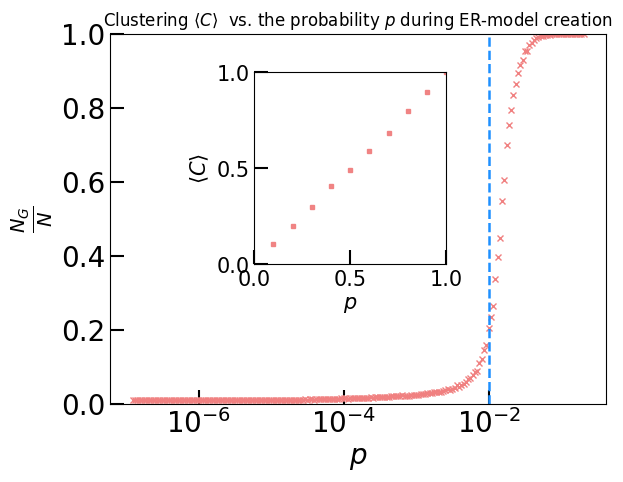

In [16]:
fig = plt.figure()
ax = fig.add_subplot(111)

ax.plot(probabilities_log_range, ratios_avg.values(), "x",  ms=5,color=COLOR_RED, label=r"$N_G / N$") # Regular values
plt.axvline(x=1./(N-1),linestyle="--", lw="1.8",color=COLOR_BLUE) # Horizontal line p_c = 1 / N

# Formatting
plt.title(r"Clustering $\langle C \rangle$  vs. the probability $p$ during ER-model creation")
ax.set_xlabel(r"$p$", fontsize=20)
ax.set_ylabel(r"$\frac{N_G}{N}$", fontsize=20)
ax.tick_params(which = "major", axis='both', width=1.5, length = 10, labelsize=20,direction="in")
ax.tick_params(which = "minor", axis='both', width=1.5, length = 5, labelsize=20,direction="in")
plt.yticks(fontsize = 20)
plt.xticks(fontsize = 20)
ax.set_ylim(0,1.0)
ax.set_xscale("log")

# Formatting
left, bottom, width, height = [0.30,0.40,0.40,0.40]
axinset = fig.add_axes([left, bottom, width, height])
axinset.plot(probabilities_log_range_cluster,clusters, 's', ms=3, c=COLOR_RED, alpha=0.95, label=r"$v(t)$")
axinset.tick_params(axis="both", width=1.5, length = 10, labelsize=15, direction="in")
axinset.set_xticks([0.,.5,1.])
axinset.set_yticks([0.,.5,1.])
axinset.set_xlim(0.,1.)
axinset.set_ylim(0.,1.)
axinset.set_aspect("equal")
axinset.set_xlabel(r"$p$", fontsize=15)
axinset.set_ylabel(r"$\langle C \rangle$", fontsize=15)

file_name = "average_clustering_for_different_probabilities.png"
complete_plot_filename = os.path.join(OUTPUT_PATH_ER, file_name)
plt.savefig(complete_plot_filename)
plt.show()

# II Watts-Strogatz Model

## 1. Write a function to generate a one-dimensional lattice with periodic boundary conditions and coordination
number k, defined as we saw in the class and assignment 1. The function should take in input two parameters:
- N: the number of nodes of the lattice,
- k: the coordination number,

and it should output a network (the data structure to represent the network is left to your choice, in the hint a suggestion is provided). You have to implement the algorithm yourself and cannot rely on modules’ functions.
Finally, produce a visualisation of a network generated using such function, with
N = 21 and k = 5.

In [17]:
random.seed(42)

In [18]:
def generate_one_dim_lattice(N, k):
    # Precondition
    if k >= N:
        raise ValueError("Coordination number k must not be larger or equal than the number of nodes in the lattice N.")

    # Create a graph object
    G = nx.Graph()
    
    # Init N nodes 
    G.add_nodes_from(range(1, N+1, 1))

    # Connect the nodes
    for i in range(1, N+1, 1):
        current_node = i
        
        # Forward edges
        for j in range(i + 1, i + k + 1, 1):
            G.add_edge(current_node, j if j <= N else j % N)  # else case handles the overflow

        # Backward edges
        for j in range(i - 1, i - k - 1, -1):
            G.add_edge(current_node, j if j > 0 else N - (abs(j) % N)) # else case handles the overflow

    return G

In [19]:
N = 21
k = 5

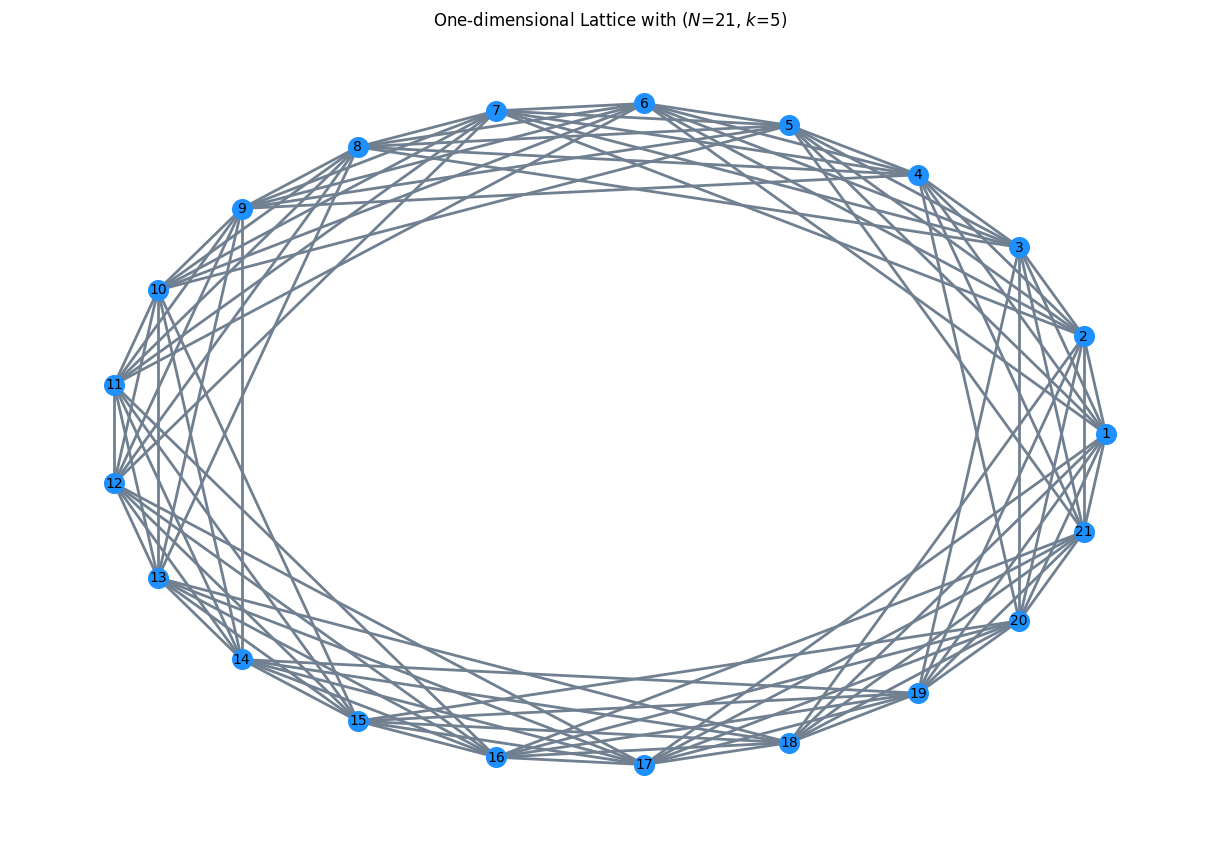

In [20]:
g = generate_one_dim_lattice(N=N, k=k)
pos = nx.circular_layout(G=g)  # Layout algorithm for node positions
plt.figure(figsize=(12, 8))
nx.draw(g, pos, with_labels=True, node_size=200, node_color=COLOR_BLUE, edge_color=COLOR_GREY, width=2, font_size=10)
plt.axis("off")
plt.title(fr"One-dimensional lattice with ($N$={N}, $k$={k})")
file_name = f"one_dim_lattice_N{N}_k{k}.png"
complete_plot_filename = os.path.join(OUTPUT_PATH_WS, file_name)
plt.savefig(complete_plot_filename)
plt.show()

## 1. Produce a plot of the average distance of each graph in a sequence of one-dimensional periodic lattices generated using the function you wrote at point 1,
where k = 10 is fixed and on the x-axis N ranges between 50 and 1000.
What is the relation between the average distance and the number of nodes?
Does it meet your expectations? Provide an interpretation of the plot.

In [21]:
k = 10

N = range(50, 1001, 1)

In [22]:
avg_shortest_paths = []

In [23]:
# Create a loading bar using tqdm
for n in tqdm(N, desc="Calculating Average Shortest Paths"):
    lattice = generate_one_dim_lattice(N=n, k=k)
    
    # Calculate the average shortest path
    avg_shortest_path = nx.average_shortest_path_length(G=lattice)
    avg_shortest_paths.append(avg_shortest_path)

Calculating Average Shortest Paths: 100%|██████████| 951/951 [07:17<00:00,  2.17it/s]


In [24]:
# Calculate the values with the formula from assignment 1
calculated_avg_nodes = []
calculated_avg_distances = []

for i, avg_shortest_path in enumerate(avg_shortest_paths):
    n = i+50
    if (n % 2 != 0) and ((n - 1) / (2 * k)).is_integer():
        d = (n-1 + 2*k) / (4*k)
        calculated_avg_nodes.append(n)
        calculated_avg_distances.append(d)
        

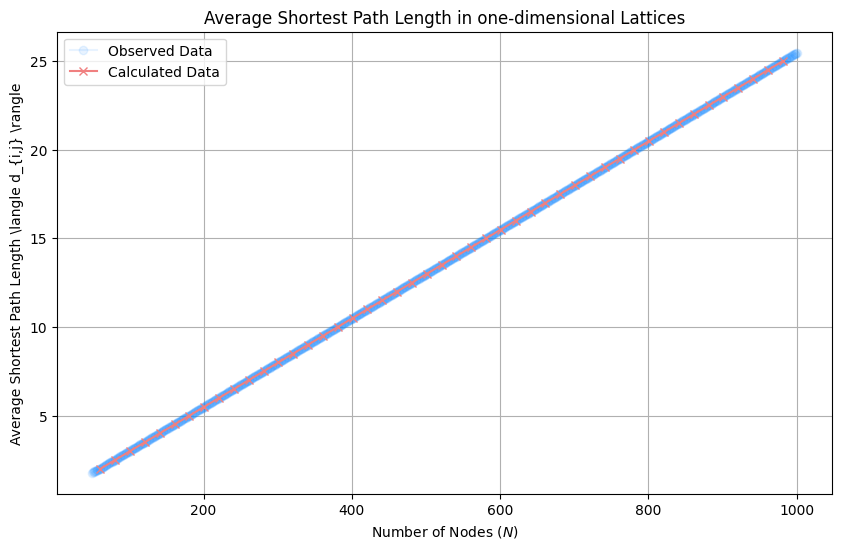

In [25]:
plt.figure(figsize=(10, 6))
plt.plot(N, avg_shortest_paths, marker="o", linestyle="-", color=COLOR_BLUE, label='Observed Data', alpha=0.1)
plt.plot(calculated_avg_nodes, calculated_avg_distances, marker='x', linestyle='-', color=COLOR_RED, label='Calculated Data', alpha=1.0)
plt.title("Average Shortest Path Length in one-dimensional Lattices")
plt.xlabel(r"Number of Nodes ($N$)")
plt.ylabel(r"Average Shortest Path Length \langle d_{i,j} \rangle")
plt.legend()
plt.grid(True)
file_name = f"average_shortest_path_one_dim_lattice.png"
complete_plot_filename = os.path.join(OUTPUT_PATH_WS, file_name)
plt.savefig(complete_plot_filename)
plt.show()

Does it meet your expectations?

Yes, the observed data, that was generated with the `generate_one_dim_lattice()` function is clearly aligned with the calculated values forme the formula in Assignment 1.


Provide an interpretation of the plot.
We have observed a linear dependency, specifically a positive correlation, between the number of nodes $N$ and the average shortest path length $\langle d_{i,j} \rangle$. This correlation is governed by the following formula:

When $N$ is odd and $\frac{N-1}{2k}$ is an integer:
$$ \langle d_{i,j} \rangle = \frac{N-1+2k}{4k} $$

The formula demonstrates that when $N$ satisfies the given conditions, the average shortest path length is determined by the expression $\frac{N-1+2k}{4k}$. In cases where $N$ falls between integer values, the plot shows a clear interpolation between data points.

## 3. Implement the original Watts-Strogatz Watts and Strogatz [1998] model, following the example we saw in the slides. It should take in input three parameters:
- $N$: the number of nodes of the network,
- $k$: the coordination number of the $1-d$ original lattice with periodic condition,
- $p$: the rewiring probability,

and it should output a network (the data structure to represent the network is left to your choice, in the hint a useful suggestion is provided). Implement the algorithm yourself and do not rely on networkx/third parties module functions. Finally, plot the network generated using such a function, for $N = 21$, $p = 0.1$, $k = 5$, using a circular layout.

You want to make sure no self-loops and multi-edges (multiple edges between the same two nodes)
happen.

In [75]:
N = 21
p = 0.1
k = 5

In [82]:
def generate_custom_watts_strogatz_graph(N, k, p, debug=False):
    # Precondition
    if p < 0 or p > 1:
        raise ValueError("Probability p must be in the range [0, 1]")
    
    g = generate_one_dim_lattice(N=N, k=k)
    
    if debug:
                plt.figure(figsize=(12, 8))
                nx.draw(g, pos, with_labels=True, node_size=200, node_color=COLOR_BLUE, edge_color=COLOR_GREY, width=2, font_size=10)
                plt.axis("off")
                plt.title(fr"Watts-Strogatz model of a one-dimensional lattice with ($N$={N}, $k$={k}, $p$={p})")
                plt.show()
    
    
    nodes = list(g.nodes())
    first_node = nodes[0]
    last_node = nodes[-1]
    #print(first_node, last_node)
    
    
    # TODO: can we use g.edges?
    for node in nodes:
        edges = list(g.edges(node))
        #print(f"Edges connected to node {node}: {edges}")
        
        for edge in edges:
            source_node, old_target_node = edge
            
            # no self-loops and multi-edges (multiple edges between the same two nodes)
            potential_targets = list(set(g.nodes()) - set([source_node]) - set(g.neighbors(source_node)))
            #print(potential_targets)
            
            
            if random.random() < p: # Change edge with probability p
                #print("Change")
                new_target_node = random.choice(potential_targets)
                #print(new_target_node)
                
                # Rewire
                g.remove_edge(source_node, old_target_node)
                g.add_edge(source_node, new_target_node)
                if debug:
                    print(f"changed {source_node} -> {old_target_node} to {source_node} -> {new_target_node}")
            else:
                if debug:
                    print("did not change anything")
                else:
                    pass
                
            #print(f"Edges connected to node {node}: {edges}")
            
            if debug:
                plt.figure(figsize=(12, 8))
                nx.draw(g, pos, with_labels=True, node_size=200, node_color=COLOR_BLUE, edge_color=COLOR_GREY, width=2, font_size=10)
                plt.axis("off")
                plt.title(fr"Watts-Strogatz model of a one-dimensional lattice with ($N$={N}, $k$={k}, $p$={p})")
                plt.show()
    return g

In [85]:
ws_graph = generate_custom_watts_strogatz_graph(N=N, k=k, p=p, debug=False)

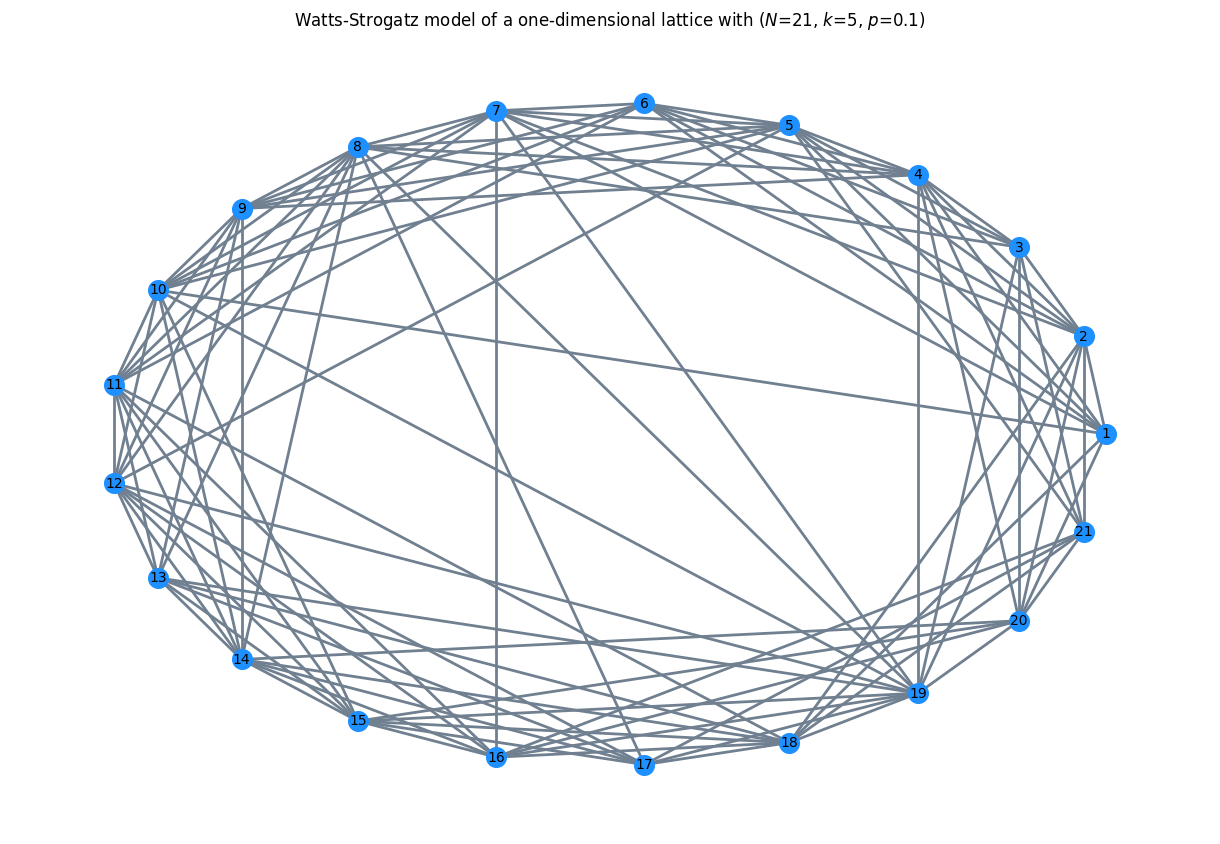

In [86]:
pos = nx.circular_layout(G=ws_graph)  # Layout algorithm for node positions
plt.figure(figsize=(12, 8))
nx.draw(ws_graph, pos, with_labels=True, node_size=200, node_color=COLOR_BLUE, edge_color=COLOR_GREY, width=2, font_size=10)

plt.axis("off")
plt.title(fr"Watts-Strogatz model of a one-dimensional lattice with ($N$={N}, $k$={k}, $p$={p})")
file_name = f"watts_strogatz_model_one_dim_lattice_N{N}_k{k}_p{p}.png"
complete_plot_filename = os.path.join(OUTPUT_PATH_WS, file_name)
plt.savefig(complete_plot_filename)
plt.show()